# Import of datasets

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from ipywidgets import interact, Dropdown

In [2]:
# Kaggle autentizace přes token
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    f.write('{"username":"vaekpeca","key":"KGAT_f4011210ab17ec755848d16cdac9665b"}')

os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)

# Stažení a rozbalení datasetu
!kaggle datasets download -d uciml/human-activity-recognition-with-smartphones
!unzip -q human-activity-recognition-with-smartphones.zip -d har_dataset
!ls har_dataset

/Users/vaclavpeca/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Dataset URL: https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones
License(s): CC0-1.0
  0%|                                               | 0.00/24.5M [00:00<?, ?B/s]
100%|██████████████████████████████████████| 24.5M/24.5M [00:00<00:00, 4.17GB/s]
test.csv  train.csv


Dataset characteristics

In [2]:
train = pd.read_csv('har_dataset/train.csv')
test = pd.read_csv('har_dataset/test.csv')

print("Velikost tabulky trénovací sady:", train.shape)
print("Velikost tabulky testovací sady:", test.shape)
print("\nNázvy sloupců:", train.columns.tolist())
print("\nTřídy:", train['Activity'].value_counts())

Velikost tabulky trénovací sady: (7352, 563)
Velikost tabulky testovací sady: (2947, 563)

Názvy sloupců: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4', 'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Y,2', 'tBodyAcc-arCoeff()-Y,3', 'tBodyAcc-arCoeff()-Y,4', 'tBodyAcc-arCoeff()-Z,1', 'tBodyAcc-arCoeff()-Z,2', 'tBodyAcc-arCoeff()-Z,3', 'tBodyAcc-arCoeff()-Z,4', 'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-X,Z',

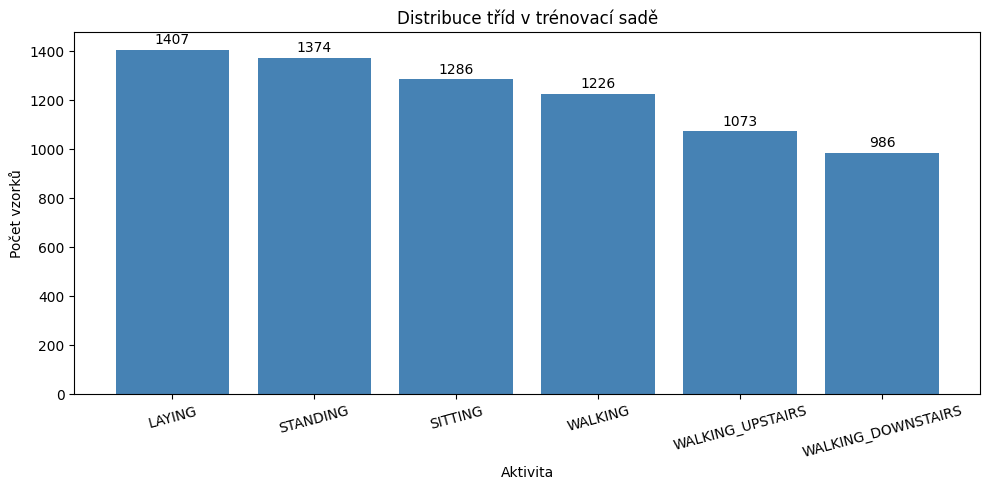

In [4]:
activity_counts = train['Activity'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(activity_counts.index, activity_counts.values, color='steelblue')
plt.title('Distribuce tříd v trénovací sadě')
plt.xlabel('Aktivita')
plt.ylabel('Počet vzorků')
plt.xticks(rotation=15)

# přidej čísla nad sloupce
for bar, val in zip(bars, activity_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [5]:
WINDOW_SECONDS = 2.56

def plot_timeline(subject_id):
    subj_data = train[train['subject'] == subject_id]['Activity'].reset_index(drop=True)

    activity_order = ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']
    colors = {'LAYING':'red', 'STANDING':'orange', 'SITTING':'gold',
              'WALKING':'green', 'WALKING_UPSTAIRS':'blue', 'WALKING_DOWNSTAIRS':'purple'}

    activity_num = subj_data.map({a: i for i, a in enumerate(activity_order)})
    color_list = subj_data.map(colors)
    time_minutes = [i * WINDOW_SECONDS / 60 for i in range(len(subj_data))]

    plt.figure(figsize=(14, 4))
    plt.scatter(time_minutes, activity_num, c=color_list, s=5, alpha=0.7)
    plt.yticks(range(len(activity_order)), activity_order)
    plt.xlabel('Čas (minuty)')
    plt.title(f'Sekvence aktivit – subjekt {subject_id}')
    plt.tight_layout()
    plt.show()

interact(plot_timeline,
         subject_id=Dropdown(options=sorted(train['subject'].unique()), description='Subjekt:'))

interactive(children=(Dropdown(description='Subjekt:', options=(np.int64(1), np.int64(3), np.int64(5), np.int6…

<function __main__.plot_timeline(subject_id)>

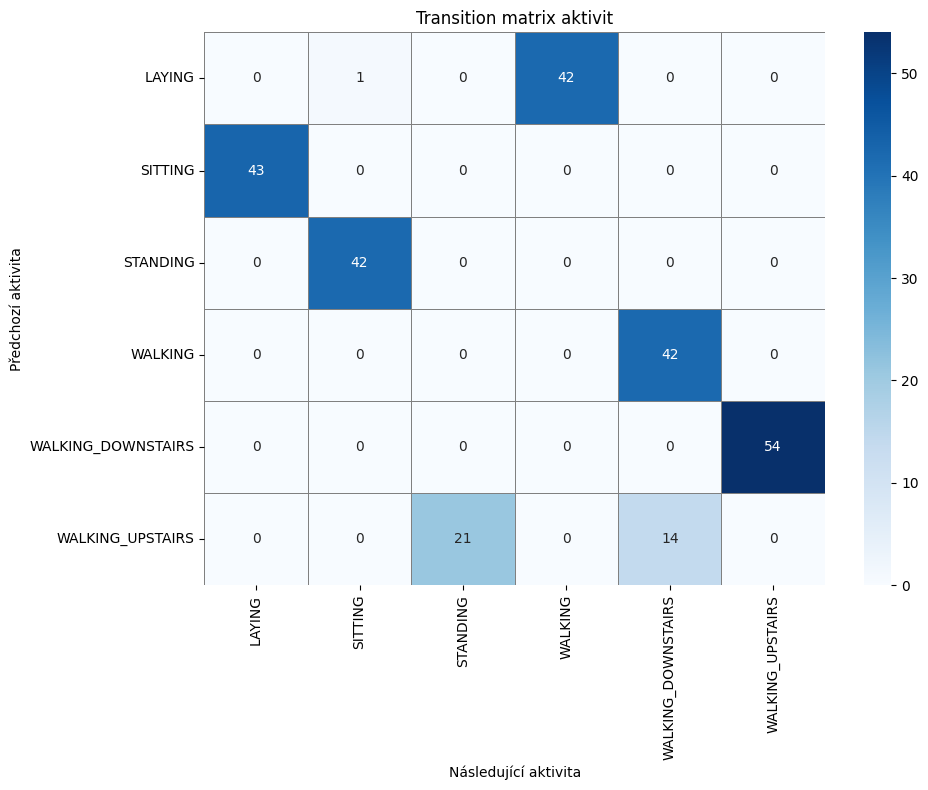

In [6]:
# Seřaď data podle subjektu (pořadí řádků zachováváme)
train_sorted = train.sort_index()

# Najdi přechody — kde se aktivita změní v rámci stejného subjektu
transitions = []
for subject in train_sorted['subject'].unique():
    subj_data = train_sorted[train_sorted['subject'] == subject]['Activity']
    for i in range(len(subj_data) - 1):
        from_activity = subj_data.iloc[i]
        to_activity = subj_data.iloc[i + 1]
        if from_activity != to_activity:  # jen přechody, ne setrvání ve stejné aktivitě
            transitions.append((from_activity, to_activity))

# Vytvoř transition matrix
trans_df = pd.DataFrame(transitions, columns=['From', 'To'])
trans_matrix = pd.crosstab(trans_df['From'], trans_df['To'])

# Vizualizace
plt.figure(figsize=(10, 8))
sns.heatmap(trans_matrix, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='gray')
plt.title('Transition matrix aktivit')
plt.xlabel('Následující aktivita')
plt.ylabel('Předchozí aktivita')
plt.tight_layout()
plt.show()

# Isolation Forest

In [7]:
X_train = train.drop(columns=['Activity', 'subject'])
y_train = train['Activity']

# Najdi outliery per třída
outlier_mask = np.zeros(len(train), dtype=bool)

for activity in y_train.unique():
    mask = (y_train == activity).values
    X_activity = X_train[mask]

    clf = IsolationForest(contamination=0.05, random_state=42) #contamination je stanovený podíl outlierů
    preds = clf.fit_predict(X_activity)

    outlier_indices = np.where(mask)[0][preds == -1]
    outlier_mask[outlier_indices] = True

print(f"Celkem outlierů: {outlier_mask.sum()}")
print("\nOutliery per třída:")
for activity in y_train.unique():
    mask = (y_train == activity).values
    n_outliers = outlier_mask[mask].sum()
    print(f"  {activity}: {n_outliers}")

Celkem outlierů: 371

Outliery per třída:
  STANDING: 69
  SITTING: 65
  LAYING: 71
  WALKING: 62
  WALKING_DOWNSTAIRS: 50
  WALKING_UPSTAIRS: 54


In [8]:
# Předpočítej scores pro všechny třídy
scores_per_activity = {}
for activity in y_train.unique():
    X_activity = X_train[y_train == activity]
    clf = IsolationForest(contamination='auto', random_state=42)
    clf.fit(X_activity)
    scores_per_activity[activity] = clf.decision_function(X_activity)

# Interaktivní graf
def plot_scores(activity):
    scores = scores_per_activity[activity]
    n_outliers = (scores < 0).sum()

    plt.figure(figsize=(10, 4))
    plt.hist(scores, bins=50, color='steelblue')
    plt.axvline(x=0, color='red', linestyle='--', label=f'hranice (score=0)')
    plt.title(f'Distribuce anomaly scores – {activity}  ({n_outliers} outlierů)')
    plt.xlabel('Anomaly score')
    plt.ylabel('Počet vzorků')
    plt.legend()
    plt.show()

interact(plot_scores, activity=Dropdown(options=sorted(y_train.unique()), description='Aktivita:'))

interactive(children=(Dropdown(description='Aktivita:', options=('LAYING', 'SITTING', 'STANDING', 'WALKING', '…

<function __main__.plot_scores(activity)>

# T-SNE

/Users/vaclavpeca/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


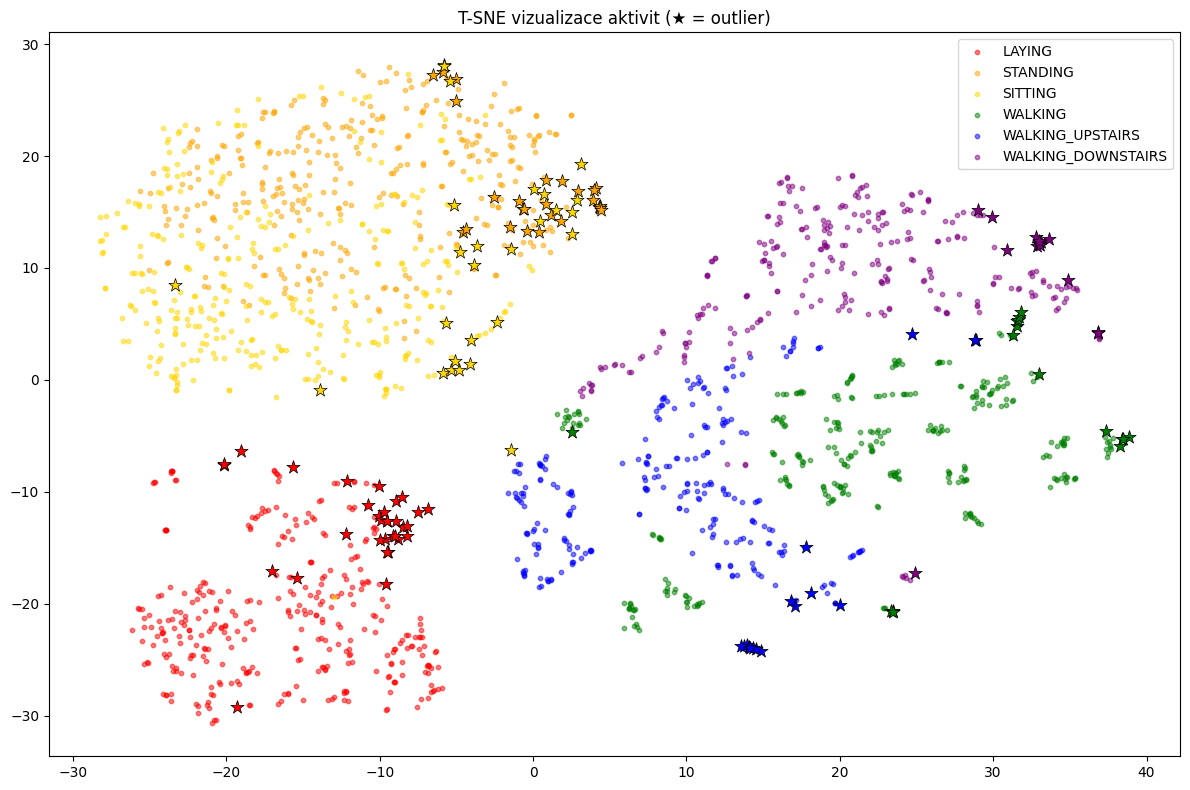

In [9]:
X_train = train.drop(columns=['Activity', 'subject'])
y_train = train['Activity']

# Podvzorek (stejný jako dřív)
sample_idx = X_train.sample(2000, random_state=42).index
X_sample = X_train.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

# Outlier detekce per třída na podvzorku
outlier_mask = np.zeros(len(X_sample), dtype=bool)
for activity in y_sample.unique():
    mask = (y_sample == activity).values
    clf = IsolationForest(contamination='auto', random_state=42)
    clf.fit(X_sample[mask])
    preds = clf.predict(X_sample[mask])
    outlier_mask[mask] = (preds == -1)

# T-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500)
X_embedded = tsne.fit_transform(X_sample)

# Vizualizace
colors = {'LAYING':'red', 'STANDING':'orange', 'SITTING':'gold',
          'WALKING':'green', 'WALKING_UPSTAIRS':'blue', 'WALKING_DOWNSTAIRS':'purple'}

plt.figure(figsize=(12, 8))
for activity, color in colors.items():
    mask = (y_sample == activity).values
    # Normální body
    plt.scatter(X_embedded[mask & ~outlier_mask, 0], X_embedded[mask & ~outlier_mask, 1],
                c=color, label=activity, alpha=0.5, s=10)
    # Outliery jako hvězdičky
    plt.scatter(X_embedded[mask & outlier_mask, 0], X_embedded[mask & outlier_mask, 1],
                c=color, marker='*', s=100, edgecolors='black', linewidths=0.5)

plt.title('T-SNE vizualizace aktivit (★ = outlier)')
plt.legend()
plt.tight_layout()
plt.show()

## XGBoost

Accuracy Score: 0.9922937443336355

Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       422
           SITTING       0.99      0.97      0.98       386
          STANDING       0.97      0.99      0.98       412
           WALKING       1.00      0.99      1.00       368
WALKING_DOWNSTAIRS       1.00      1.00      1.00       296
  WALKING_UPSTAIRS       0.99      1.00      1.00       322

          accuracy                           0.99      2206
         macro avg       0.99      0.99      0.99      2206
      weighted avg       0.99      0.99      0.99      2206



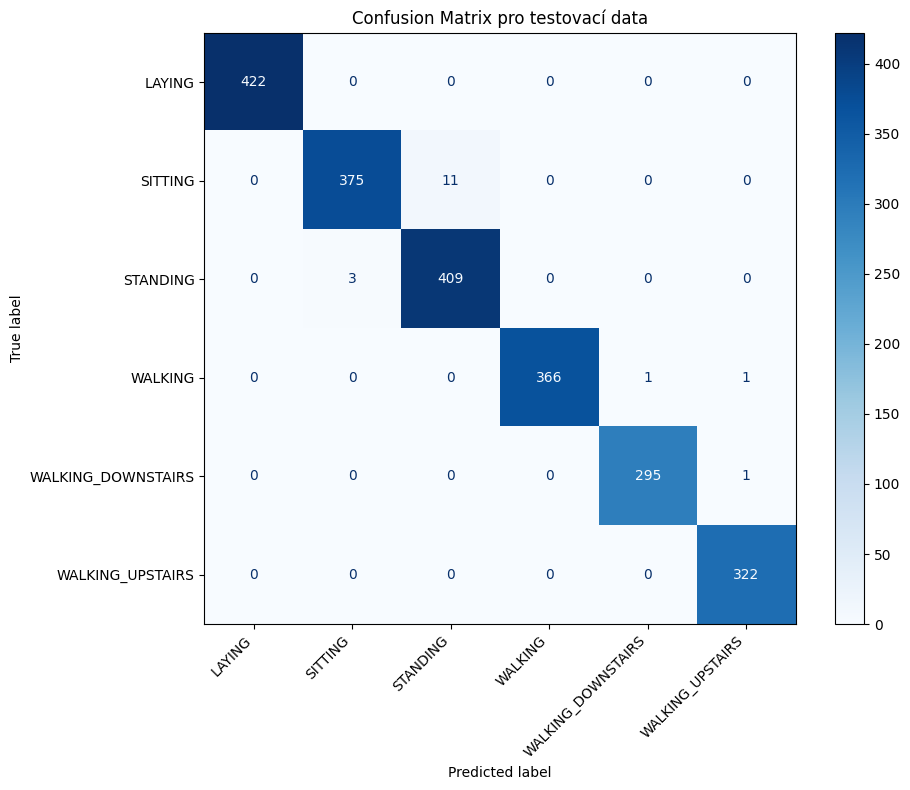

In [4]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Příprava dat
X = train.drop(columns=['Activity', 'subject'])
y = train['Activity']

# Převedení aktivit na číselné hodnoty
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Rozdělení dat na trénovací a validační sady
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Inicializace a trénování XGBoost modelu
xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(le.classes_), random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)

# Predikce a vyhodnocení
y_pred_xgb = xgb_model.predict(X_test_xgb)

print("Accuracy Score:", accuracy_score(y_test_xgb, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test_xgb, y_pred_xgb, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test_xgb, y_pred_xgb, labels=xgb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix pro testovací data')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Random Forest + Optuna HPO

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

# ── Data preparation ──────────────────────────────────────────────────────────
train = pd.read_csv('har_dataset/train.csv')
test  = pd.read_csv('har_dataset/test.csv')

X_train = train.drop(columns=['Activity', 'subject'])
y_train = train['Activity']

X_test  = test.drop(columns=['Activity', 'subject'])
y_test  = test['Activity']

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Classes: {sorted(y_train.unique())}")


Train: (7352, 561)  |  Test: (2947, 561)
Classes: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


In [6]:
# ── Optuna HPO ────────────────────────────────────────────────────────────────
N_TRIALS   = 30
CV_FOLDS   = 3
RANDOM_STATE = 42

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

trial_scores = []   # (trial_number, cv_accuracy)

def objective(trial):
    params = dict(
        n_estimators  = trial.suggest_int('n_estimators',    50, 400),
        max_depth      = trial.suggest_int('max_depth',        5,  30),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1,   5),
        max_features   = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        random_state   = RANDOM_STATE,
        n_jobs         = -1,
    )
    clf    = RandomForestClassifier(**params)
    scores = cross_val_score(clf, X_train, y_train,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    mean_acc = scores.mean()
    trial_scores.append((trial.number, mean_acc))
    return mean_acc

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study   = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
best_cv     = study.best_value

print("\n" + "="*55)
print("Best hyperparameters:")
for k, v in best_params.items():
    print(f"  {k:20s}: {v}")
print(f"\nBest CV accuracy : {best_cv:.4f}  ({best_cv*100:.2f} %)")
print("="*55)


  0%|          | 0/30 [00:00<?, ?it/s]


Best hyperparameters:
  n_estimators        : 354
  max_depth           : 20
  min_samples_leaf    : 1
  max_features        : sqrt

Best CV accuracy : 0.9808  (98.08 %)


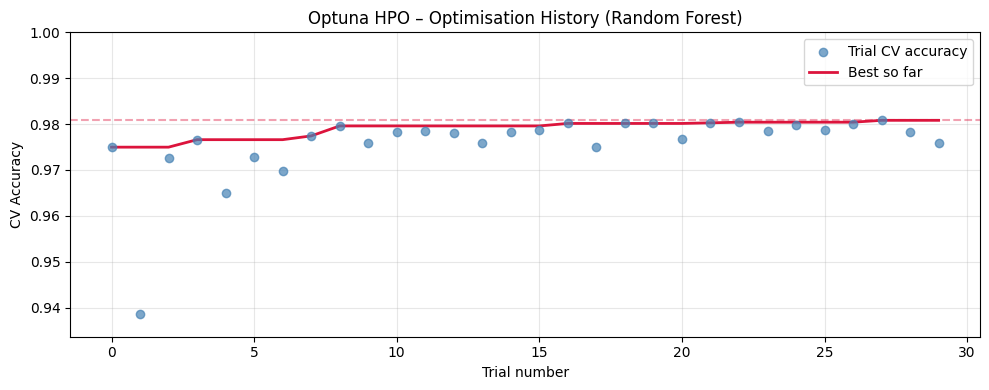

In [7]:
# ── HPO optimisation history ──────────────────────────────────────────────────
trial_nums, scores = zip(*sorted(trial_scores, key=lambda x: x[0]))
best_so_far = np.maximum.accumulate(scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(trial_nums, scores, color='steelblue', alpha=0.7, zorder=3,
           label='Trial CV accuracy')
ax.plot(trial_nums, best_so_far, color='crimson', linewidth=2,
        label='Best so far')
ax.axhline(best_cv, color='crimson', linestyle='--', alpha=0.4)
ax.set_xlabel('Trial number')
ax.set_ylabel('CV Accuracy')
ax.set_title('Optuna HPO – Optimisation History (Random Forest)')
ax.legend()
ax.set_ylim(min(scores) - 0.005, 1.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Final model + OOB convergence

  n_estimators=  50  OOB=0.9793
  n_estimators= 100  OOB=0.9822
  n_estimators= 150  OOB=0.9838
  n_estimators= 200  OOB=0.9826
  n_estimators= 250  OOB=0.9816
  n_estimators= 300  OOB=0.9829
  n_estimators= 350  OOB=0.9831
  n_estimators= 354  OOB=0.9834

Final OOB accuracy: 0.9834  (98.34 %)


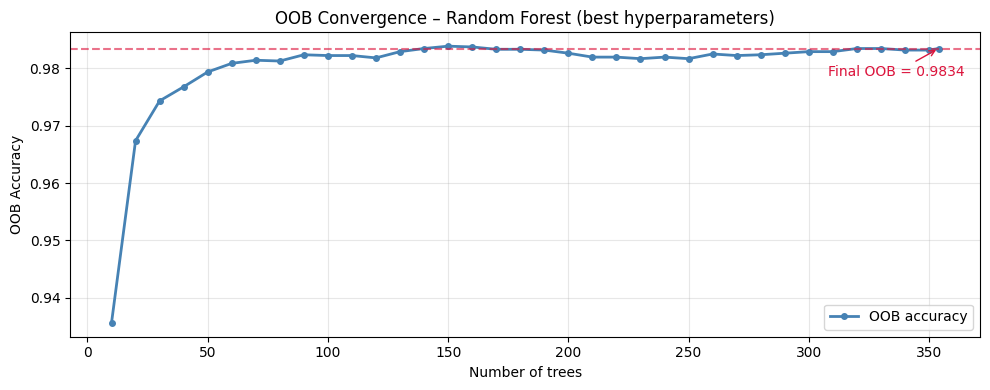

In [12]:
# ── Train final model & track OOB convergence ─────────────────────────────────
best_n = best_params['n_estimators']
step   = 10
n_range = list(range(step, best_n + 1, step))
if n_range[-1] != best_n:
    n_range.append(best_n)

oob_scores = []
for n in n_range:
    rf = RandomForestClassifier(
        n_estimators     = n,
        max_depth        = best_params['max_depth'],
        min_samples_leaf = best_params['min_samples_leaf'],
        max_features     = best_params['max_features'],
        oob_score        = True,
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
    )
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)
    if n % 50 == 0 or n == best_n:
        print(f"  n_estimators={n:4d}  OOB={rf.oob_score_:.4f}")

final_oob = oob_scores[-1]
print(f"\nFinal OOB accuracy: {final_oob:.4f}  ({final_oob*100:.2f} %)")

# keep the final fitted model for evaluation
rf_final = rf

# ── OOB convergence curve ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(n_range, oob_scores, color='steelblue', linewidth=2, marker='o',
        markersize=4, label='OOB accuracy')
ax.axhline(final_oob, color='crimson', linestyle='--', alpha=0.6)
ax.annotate(f'Final OOB = {final_oob:.4f}',
            xy=(n_range[-1], final_oob),
            xytext=(-80, -20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='crimson'),
            color='crimson', fontsize=10)
ax.set_xlabel('Number of trees')
ax.set_ylabel('OOB Accuracy')
ax.set_title('OOB Convergence – Random Forest (best hyperparameters)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test-set evaluation

In [13]:
# ── Test-set evaluation ───────────────────────────────────────────────────────
y_pred = rf_final.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print("="*45)
print(f"  Test Accuracy (macro)  : {acc:.4f}  ({acc*100:.2f} %)")
print(f"  Test F1  (macro-avg)   : {f1:.4f}  ({f1*100:.2f} %)")
print("="*45)
print()
print(classification_report(y_test, y_pred, digits=4))


  Test Accuracy (macro)  : 0.9284  (92.84 %)
  Test F1  (macro-avg)   : 0.9267  (92.67 %)

                    precision    recall  f1-score   support

            LAYING     1.0000    1.0000    1.0000       537
           SITTING     0.9158    0.8859    0.9006       491
          STANDING     0.8978    0.9248    0.9111       532
           WALKING     0.9004    0.9657    0.9319       496
WALKING_DOWNSTAIRS     0.9651    0.8571    0.9079       420
  WALKING_UPSTAIRS     0.8983    0.9193    0.9087       471

          accuracy                         0.9284      2947
         macro avg     0.9296    0.9255    0.9267      2947
      weighted avg     0.9295    0.9284    0.9282      2947



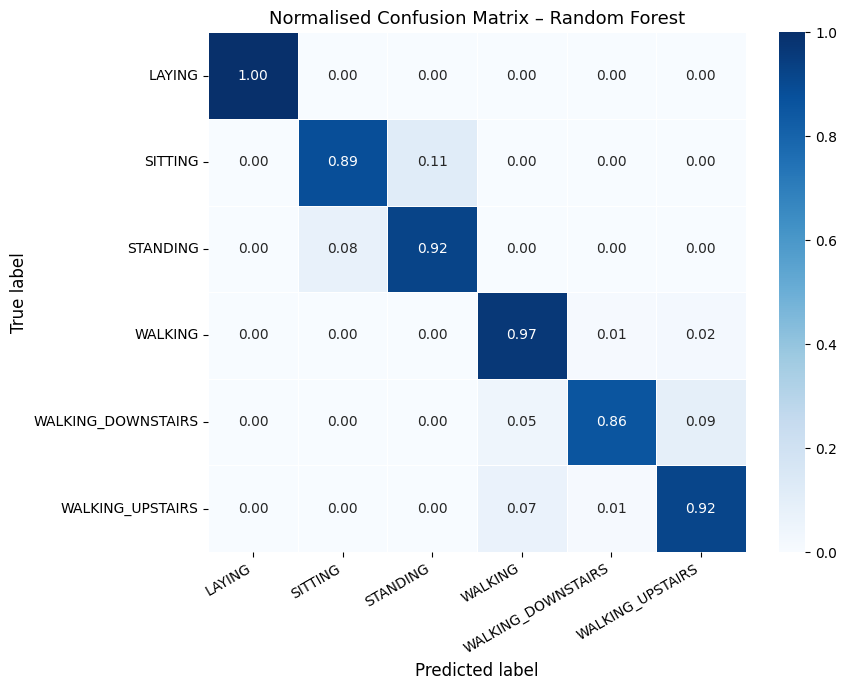

In [14]:
# ── Normalised confusion matrix ───────────────────────────────────────────────
classes   = sorted(y_test.unique())
cm_raw    = confusion_matrix(y_test, y_pred, labels=classes)
cm_norm   = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='white',
            vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Normalised Confusion Matrix – Random Forest', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


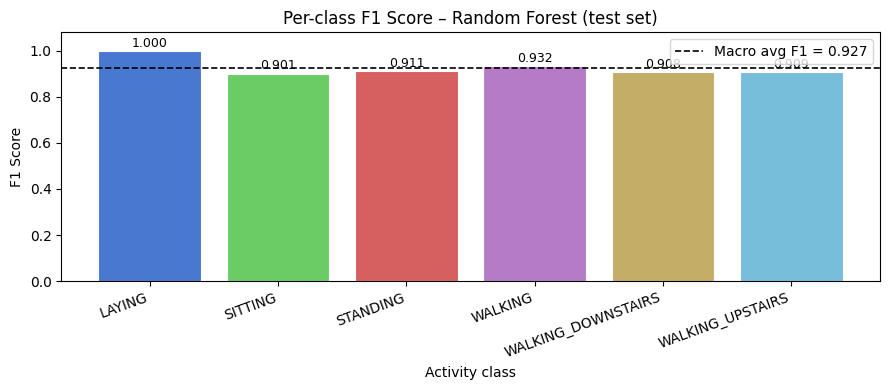

In [15]:
# ── Per-class F1 bar chart ────────────────────────────────────────────────────
from sklearn.metrics import f1_score as _f1

classes   = sorted(y_test.unique())
f1_scores = _f1(y_test, y_pred, average=None, labels=classes)

palette = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66', '#77BEDB']
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(classes, f1_scores, color=palette[:len(classes)], edgecolor='white',
              linewidth=0.8)
ax.axhline(f1_scores.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Macro avg F1 = {f1_scores.mean():.3f}')
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.08)
ax.set_xlabel('Activity class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 Score – Random Forest (test set)')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
